# 05 — MCMC Fitting a Grating Spectrum

This notebook demonstrates MCMC fitting on a G395M grating spectrum
where individual lines are resolved.  It covers:
1. MCMC fit with BIC-based broad Balmer selection (the default)
2. Convergence diagnostics (R-hat, ESS)
3. Corner plots of correlated parameters (e.g. [NII]/Ha)
4. Flux-ratio posteriors: O3/Hb and N2/Ha for BPT diagnostics
5. Nautilus nested sampler as an alternative to emcee
6. Compare MLE, bootstrap, and MCMC uncertainties
7. Forcing a specific broad mode

In [1]:
import jwspecfit
import jwspecmcmc
import matplotlib.pyplot as plt
import numpy as np
import numpyro
numpyro.set_host_device_count(6)

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"jwspecmcmc v{jwspecmcmc.__version__}")

jwspecfit  v1.0.1
jwspecmcmc v1.0.1


## Load the G395M spectrum

Same grating spectrum as notebook 02.  The G395M has R ≈ 1000,
resolving [NII] from Hα and the [SII] doublet.

In [2]:
spec = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits",
    z=6.1052,
)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} \u2013 {spec.wave_um.max():.3f} \u00b5m")

Grating:    G395M
Pixels:     1661
Wave range: 2.680 – 5.510 µm


## Quick look at the raw spectrum

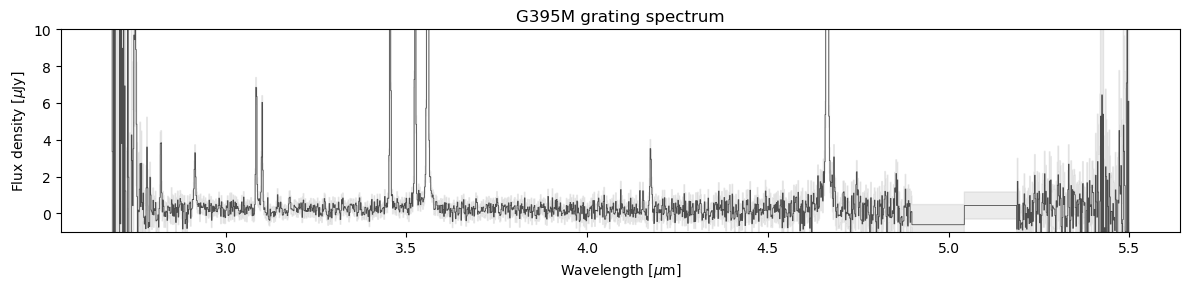

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
valid = spec.mask_valid()
ax.step(spec.wave_um[valid], spec.flux_ujy[valid], where="mid", lw=0.6, color="0.3")
ax.fill_between(
    spec.wave_um[valid],
    (spec.flux_ujy - spec.err_ujy)[valid],
    (spec.flux_ujy + spec.err_ujy)[valid],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylim(-1,10)
ax.set_ylabel(r"Flux density [$\mu$Jy]")
ax.set_title("G395M grating spectrum")
plt.tight_layout()

## MCMC fit with nuts

Fit all observable lines using emcee.  By default (`mode="auto"`),
BIC model selection checks for broad Balmer components before
running MCMC on the winning model.

In [8]:
lines = ["OII_doublet", "HEPSILON", "HDELTA","HGAMMA", "OIII_4363", "OIII_4959", "OIII_5007",
    "HBETA",   "H10",
    "H9","H8", "HEI_4472","NeIII_3869",'Ha','NII_6585'
]

result = jwspecmcmc.fit_lines(
    spec, z=6.1052,
    sampler="nuts",
    n_warmup=500, n_samples_nuts=2000, n_chains=6,
    n_boot_bic=0,  
    deg=3,
    seed=42,
    lines=lines,

)

print(f"Selected:    {result.selected_model}")
print(f"Sampler:     {result.sampler_name}")
print(f"Lines:       {len(result.lines)} fitted")
print(f"Chain shape: {result.flat_chains.shape}")
print(f"Burn-in:     {result.sampler_meta.get('n_burn', '?')} steps")
print(f"BIC narrow:  {result.bic_narrow:.1f}")
print(f"BIC broad1:  {result.bic_broad1:.1f}")

Resolving power: R = 1000
Resolving power: R = 1000
Resolving power: R = 1000


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

W0504 20:43:52.781373 38114476 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Selected:    broad1
Sampler:     nuts
Lines:       18 fitted
Chain shape: (12000, 54)
Burn-in:     ? steps
BIC narrow:  1924.2
BIC broad1:  1819.8


## Per-line results

Asymmetric 68% credible intervals from the posterior.

In [9]:
print(f"{'Line':<22s} {'Flux':>12s} {'−err':>12s} {'+err':>12s} {'SNR':>8s} {'EW (Å)':>10s}")
print("-" * 80)
for name, lr in result.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(
        f"{name + tag:<22s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e} {lr.flux_err[1]:12.3e}"
        f" {lr.snr:8.1f} {lr.ew_A:10.1f}"
    )

Line                           Flux         −err         +err      SNR     EW (Å)
--------------------------------------------------------------------------------
HEPSILON                  5.100e-18    6.441e-19    6.246e-19      8.0      102.0
HDELTA                    1.957e-18    7.348e-19    6.502e-19      2.8       37.5
HGAMMA                    6.206e-18    9.091e-19    7.822e-19      7.3      117.5
OIII_4363                 6.104e-18    3.752e-19    3.923e-19     15.9      115.9
OIII_4959                 2.998e-17    5.260e-19    5.229e-19     57.2      694.1
OIII_5007                 8.770e-17    8.493e-19    8.399e-19    103.8     2080.4
HBETA                     1.556e-17    7.561e-19    6.240e-19     22.5      344.0
H10                       2.560e-17    1.885e-17    3.328e-17      1.0      580.3
H9                        4.923e-18    3.641e-18    6.606e-18      1.0      107.6
H8                        3.013e-18    1.759e-18    1.995e-18      1.6       63.2
HEI_4472         

## Convergence diagnostics

Check that the chains have converged: R-hat < 1.05 and ESS > 100.

In [10]:
conv = result.convergence
print(f"R-hat max:  {conv.get('r_hat_max', 'N/A'):.4f}")
print(f"ESS min:    {conv.get('ess_min', 'N/A'):.0f}")
print(f"Converged:  {conv.get('converged', 'N/A')}")

if 'r_hat' in conv:
    r_hat = conv['r_hat']
    print(f"\nR-hat range: {np.nanmin(r_hat):.4f} \u2013 {np.nanmax(r_hat):.4f}")
    n_bad = np.sum(r_hat > 1.05)
    if n_bad > 0:
        print(f"WARNING: {n_bad} parameters have R-hat > 1.05")

R-hat max:  1.0009
ESS min:    2633
Converged:  True

R-hat range: 0.9998 – 1.0009


## Trace plots

Visualise chain mixing for key parameters.

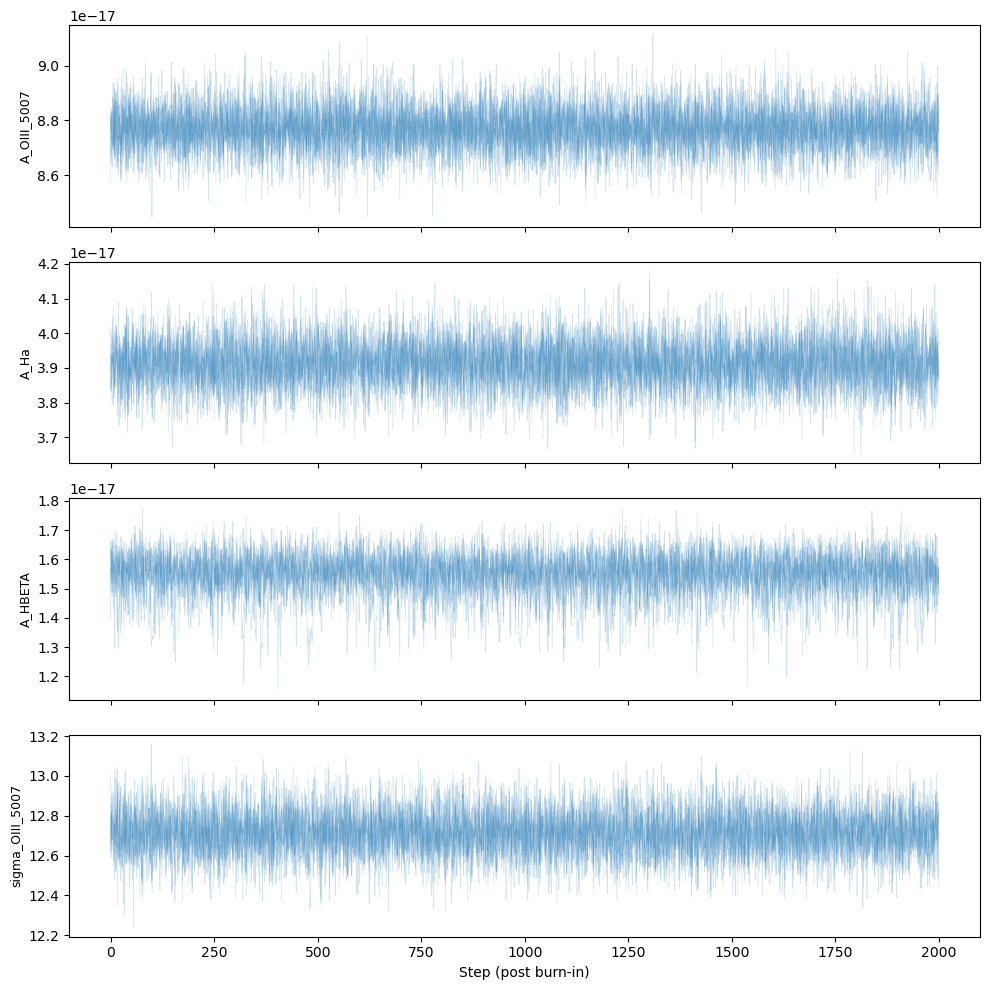

In [11]:
fig = jwspecmcmc.plot_traces(
    result,
    params=["A_OIII_5007", "A_Ha", "A_HBETA", "sigma_OIII_5007"],
)
plt.show()

In [12]:
fig = jwspecfit.plot_fit_interactive(result)
fig

## Flux posterior histograms

Posterior distributions for the brightest lines.

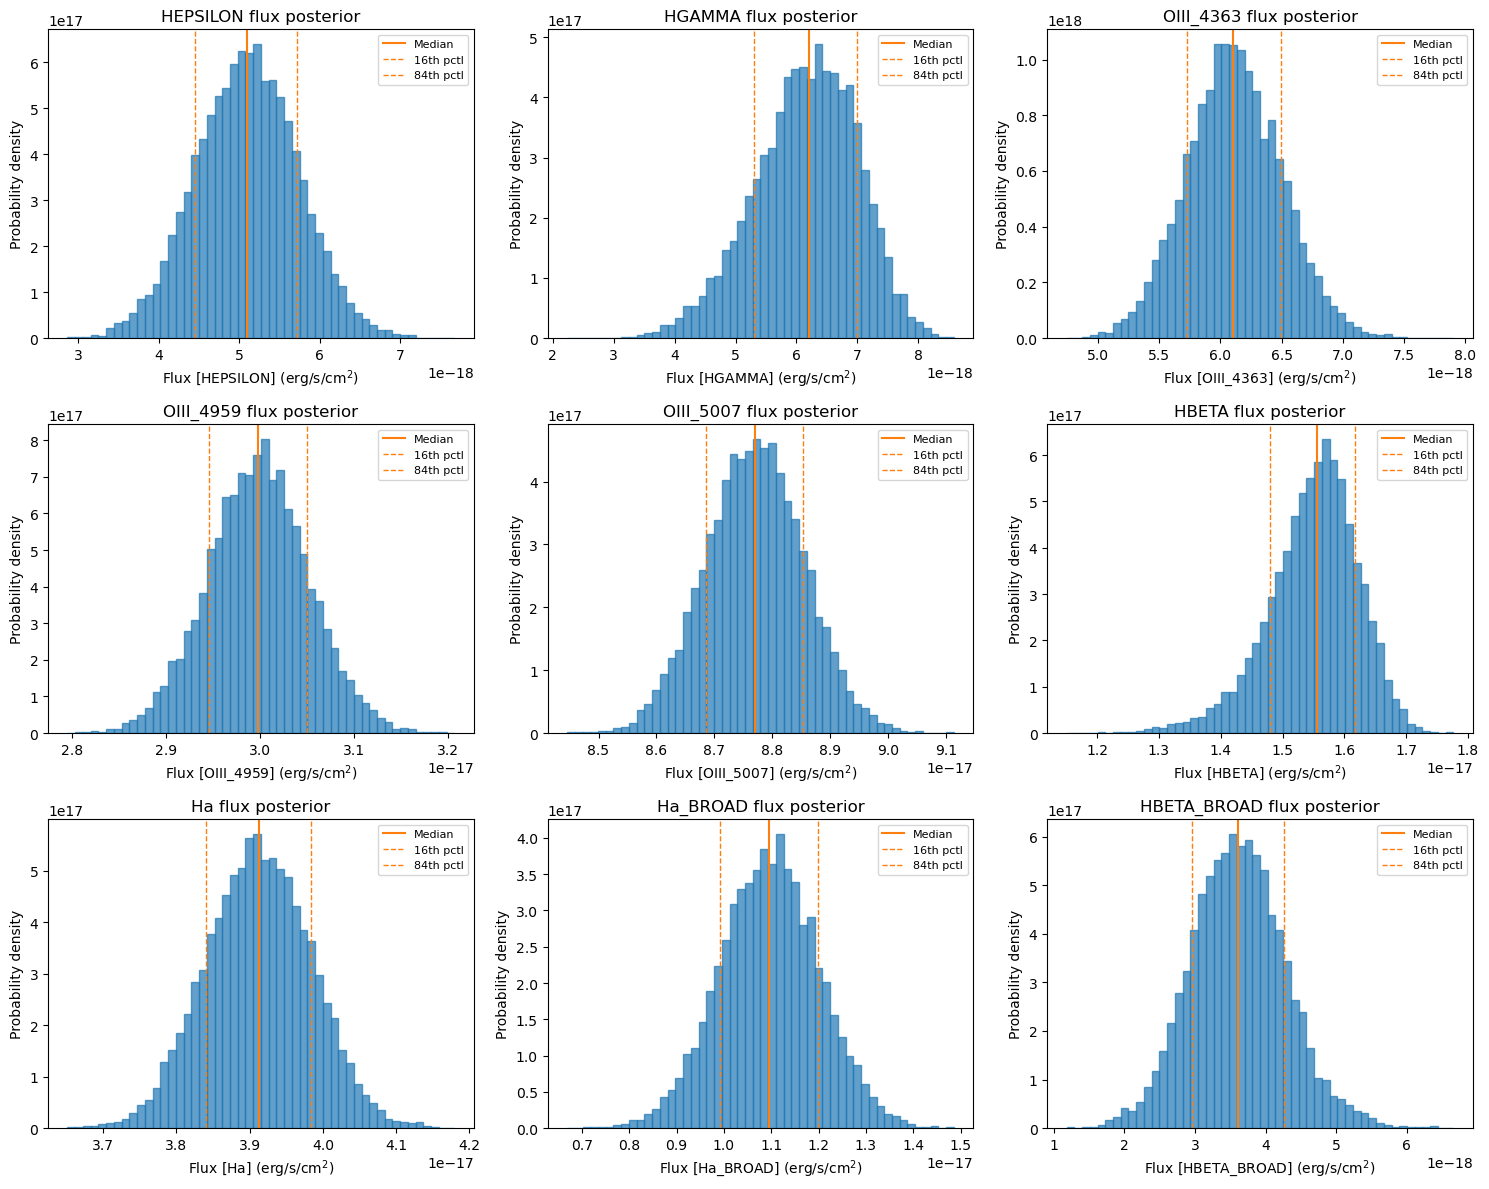

In [13]:
bright_lines = [name for name, lr in result.lines.items() if lr.snr > 5]
n_bright = len(bright_lines)

if n_bright > 0:
    ncols = min(n_bright, 3)
    nrows = (n_bright + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, line in zip(axes, bright_lines):
        jwspecmcmc.plot_flux_posterior(result, line, ax=ax)
    for ax in axes[n_bright:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No lines with SNR > 5.")

## Corner plot: Hα + [NII] complex

Joint posterior of Hα and [NII] 6585 amplitudes and the OIII sigma.

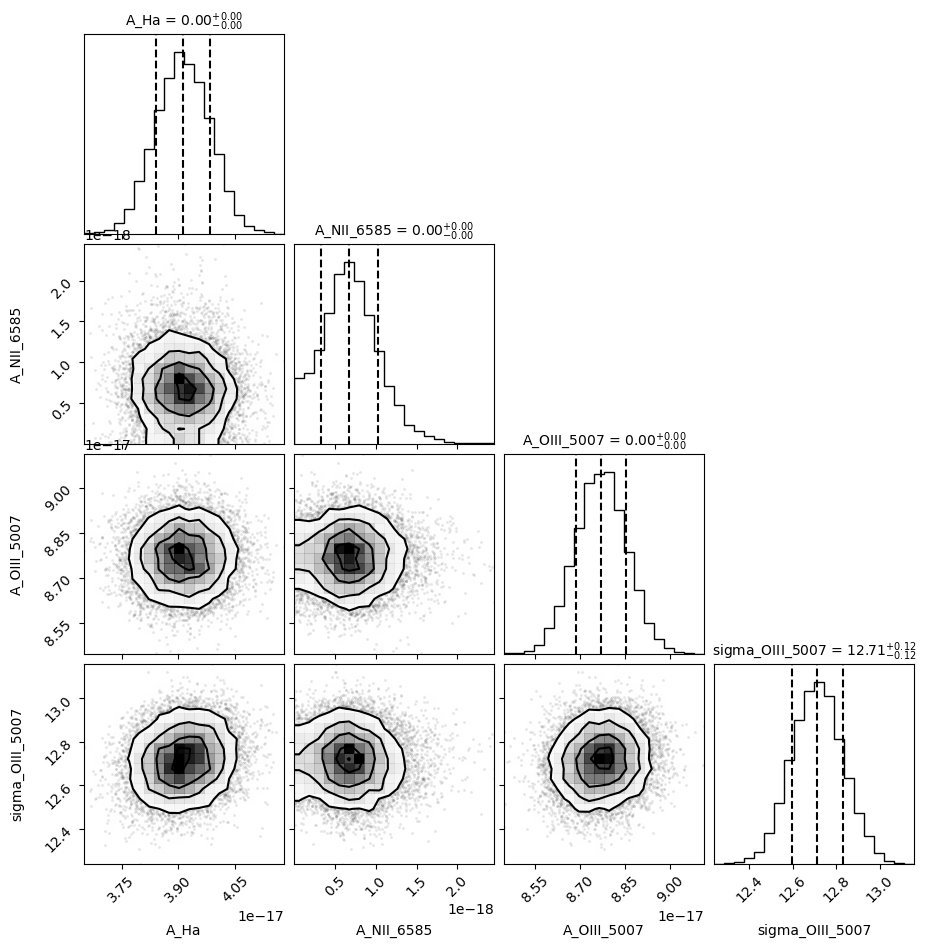

In [14]:
corner_params = ["A_Ha", "A_NII_6585", "A_OIII_5007", "sigma_OIII_5007"]
# Only include params that are in the result
corner_params = [p for p in corner_params if p.split("_", 1)[1] in result.lines or
                 p.replace("sigma_", "") in result.lines or
                 p.replace("mu_", "") in result.lines]

if len(corner_params) >= 2:
    fig = jwspecmcmc.plot_corner(result, params=corner_params)
    plt.show()

## Flux-ratio posteriors for BPT diagnostics

Compute the posteriors on log([OIII] 5007 / Hβ) and
log([NII] 6585 / Hα) — the standard BPT axes.

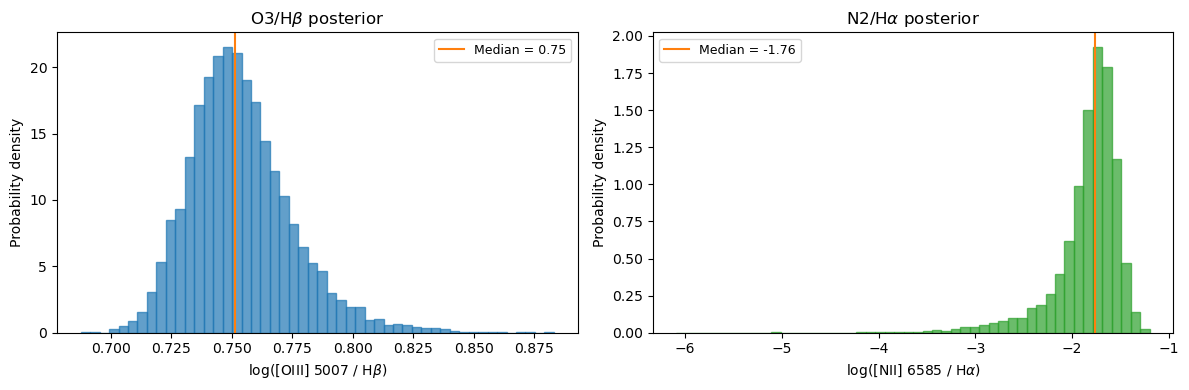

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# O3/Hbeta
if "OIII_5007" in result.lines and "HBETA" in result.lines:
    ratio_o3hb = result.flux_ratio_posterior("OIII_5007", "HBETA")
    ratio_o3hb = ratio_o3hb[np.isfinite(ratio_o3hb) & (ratio_o3hb > 0)]
    if len(ratio_o3hb) > 0:
        log_o3hb = np.log10(ratio_o3hb)
        axes[0].hist(log_o3hb, bins=50, density=True, alpha=0.7, color="C0", edgecolor="C0")
        med = np.median(log_o3hb)
        axes[0].axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.2f}")
        axes[0].set_xlabel(r"log([OIII] 5007 / H$\beta$)")
        axes[0].set_ylabel("Probability density")
        axes[0].legend(fontsize=9)
        axes[0].set_title(r"O3/H$\beta$ posterior")

# N2/Halpha
if "NII_6585" in result.lines and "Ha" in result.lines:
    ratio_n2ha = result.flux_ratio_posterior("NII_6585", "Ha")
    ratio_n2ha = ratio_n2ha[np.isfinite(ratio_n2ha) & (ratio_n2ha > 0)]
    if len(ratio_n2ha) > 0:
        log_n2ha = np.log10(ratio_n2ha)
        axes[1].hist(log_n2ha, bins=50, density=True, alpha=0.7, color="C2", edgecolor="C2")
        med = np.median(log_n2ha)
        axes[1].axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.2f}")
        axes[1].set_xlabel(r"log([NII] 6585 / H$\alpha$)")
        axes[1].set_ylabel("Probability density")
        axes[1].legend(fontsize=9)
        axes[1].set_title(r"N2/H$\alpha$ posterior")

plt.tight_layout()
plt.show()

## Plot the MCMC fit

Convert to `FitResult` and use `plot_fit()` for the standard
data + model + residuals view.

χ²/dof = 1.09


/Users/raunaqrai/Documents/phd/y1/jwspecfit/src/jwspecfit/plotting.py:376: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



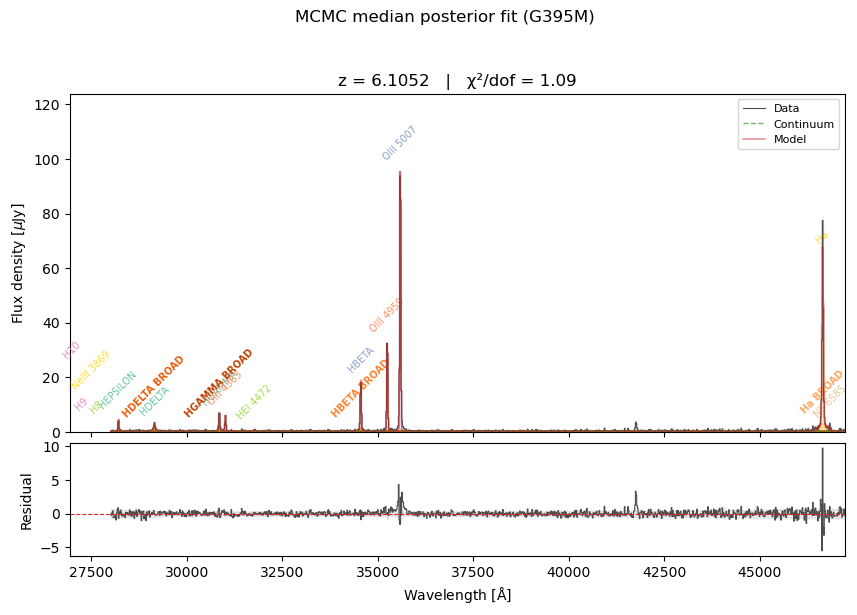

In [16]:
fit_result = result.to_fit_result()
print(f"\u03c7\u00b2/dof = {fit_result.chi2:.2f}")

fig = jwspecfit.plot_fit(fit_result, exclude_wave_A=[(20000, 28000), (50000, 60000)])
fig.suptitle("MCMC median posterior fit (G395M)", y=1.02)
plt.show()

In [17]:
fig_interactive = jwspecfit.plot_fit_interactive(fit_result)
fig_interactive.show()

## Compare MLE and MCMC uncertainties

Run the standard bootstrap fit (narrow-only) and compare error bars
with the MCMC result.

In [20]:
result_lsq = jwspecfit.fit_lines(spec, z=6.1052, deg=3, n_boot=100, mode="off",lines=lines)

print(f"{'Line':<18s} {'Flux':>12s} {'Boot err':>12s} {'MCMC −err':>12s} {'MCMC +err':>12s}")
print("-" * 70)
for name in result_lsq.lines:
    if name in result.lines:
        lr_lsq = result_lsq.lines[name]
        lr_mc = result.lines[name]
        print(
            f"{name:<18s} {lr_lsq.flux:12.3e} {lr_lsq.flux_err:12.3e}"
            f" {lr_mc.flux_err[0]:12.3e} {lr_mc.flux_err[1]:12.3e}"
        )

Resolving power: R = 1000


Bootstrap: 100%|██████████| 100/100 [00:04<00:00, 23.50iter/s]

Line                       Flux     Boot err    MCMC −err    MCMC +err
----------------------------------------------------------------------
HEPSILON              5.159e-18    7.150e-19    6.441e-19    6.246e-19
HDELTA                3.758e-18    3.917e-19    7.348e-19    6.502e-19
HGAMMA                7.948e-18    4.585e-19    9.091e-19    7.822e-19
OIII_4363             6.087e-18    3.733e-19    3.752e-19    3.923e-19
OIII_4959             2.999e-17    5.128e-19    5.260e-19    5.229e-19
OIII_5007             8.790e-17    7.981e-19    8.493e-19    8.399e-19
HBETA                 1.719e-17    4.048e-19    7.561e-19    6.240e-19
H10                   5.638e-54    3.926e-20    1.885e-17    3.328e-17
H9                    6.904e-53    4.221e-29    3.641e-18    6.606e-18
H8                    2.740e-18    2.060e-18    1.759e-18    1.995e-18
HEI_4472              9.103e-19    3.320e-19    3.907e-19    4.083e-19
NeIII_3869            3.496e-17    8.792e-18    8.334e-18    8.857e-18
Ha    

## Nautilus nested sampler

As an alternative to emcee, you can use `nautilus` for nested sampling.
This automatically computes the Bayesian evidence and does not require
burn-in tuning.  Note: trace plots are not available for nautilus.

In [ ]:
result_naut = jwspecmcmc.fit_lines(
    spec, z=6.1052,
    sampler="nautilus",
    lines=["OIII_4959", "OIII_5007", "HBETA", "Ha", "NII_6549", "NII_6585"],
    mode="off",
    deg=3,
    n_live=1000,
    n_eff=5000,
)

print(f"Sampler: {result_naut.sampler_name}")
print(f"Samples: {result_naut.flat_chains.shape[0]}")
print()
for name, lr in result_naut.lines.items():
    print(f"  {name:<18s} flux={lr.flux:.3e} (-{lr.flux_err[0]:.3e}, +{lr.flux_err[1]:.3e})  SNR={lr.snr:.1f}")

## Forcing a specific broad mode

The default `mode="auto"` lets BIC decide.  You can also force a
specific model with `mode="broad1"`, `"broad2"`, `"both"`, or call
`jwspecmcmc.fit_with_broad()` directly for explicit control.

Here we force the intermediate broad component:

In [ ]:
result_forced = jwspecmcmc.fit_lines(
    spec, z=6.1052,
    sampler="emcee",
    mode="broad1",       # force intermediate broad (skip BIC)
    n_steps=3000,
    deg=3,
    seed=42,
)

print(f"Selected model: {result_forced.selected_model}")
print(f"Lines fitted:   {result_forced.line_names}")
print(f"Chain shape:    {result_forced.flat_chains.shape}")

### Broad-fit per-line results

If broad components were selected, they appear alongside the narrow lines.

In [ ]:
print(f"{'Line':<22s} {'Flux':>12s} {'−err':>12s} {'+err':>12s} {'SNR':>8s}")
print("-" * 70)
for name, lr in result_forced.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(
        f"{name + tag:<22s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e} "
        f"{lr.flux_err[1]:12.3e} {lr.snr:8.1f}"
    )

### Plot the broad-fit model

Convert to `FitResult` and plot data + model + residuals.

In [ ]:
fit_forced = result_forced.to_fit_result()
print(f"χ²/dof = {fit_forced.chi2:.2f}")

fig = jwspecfit.plot_fit(fit_forced, exclude_wave_A=[(20000, 28000), (50000, 60000)])
fig.suptitle(f"Forced broad1 model (G395M)", y=1.02)
plt.show()

In [ ]:
fig_interactive = jwspecfit.plot_fit_interactive(fit_forced)
fig_interactive.show()